# Rain in Australia: preparing incomplete weather data

University group project: Jing Ting Oh, Jesslyn Xiao Xuan Tan, Jin Wan Kim and Jinghan Wu.
My submitted contribution was exploration, feature engineering and preprocessing (sections a and b).
The group supplied the model-training and evaluation sections.

This portfolio revision moves the split before target-based exploration and makes the small search reproducible.
The implementation below is a maintained version, not an unchanged submission.
Earlier analysis used this dataset and split, so this is not a new, untouched external benchmark.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df_all = pd.read_csv('weatherAUS.csv')
labelled = df_all.dropna(subset=['RainTomorrow']).copy()
train_df, test_df = train_test_split(
    labelled, test_size=0.2, stratify=labelled['RainTomorrow'], random_state=42)
print('Source rows:', len(df_all), '| labelled:', len(labelled))
print('Training rows:', len(train_df), '| held-out rows:', len(test_df))
assert set(train_df.index).isdisjoint(test_df.index)
image_dir = Path('../images')
image_dir.mkdir(exist_ok=True)


Source rows: 145460 | labelled: 142193
Training rows: 113754 | held-out rows: 28439


## 1. Missing values and target association

Only the training partition is used for the following comparisons. Missingness alone is not a reason to discard a column.
Pearson correlation is a screening measure here, not a complete measure of predictive value.


,missing_pct,abs_correlation
Sunshine,47.773,0.450
Evaporation,42.807,0.119
Cloud3pm,40.147,0.382
Cloud9am,37.693,0.317
Pressure9am,9.922,0.246
Pressure3pm,9.900,0.226
WindGustSpeed,6.540,0.233
Humidity3pm,2.547,0.445
Temp3pm,1.937,0.193
WindSpeed3pm,1.872,0.087


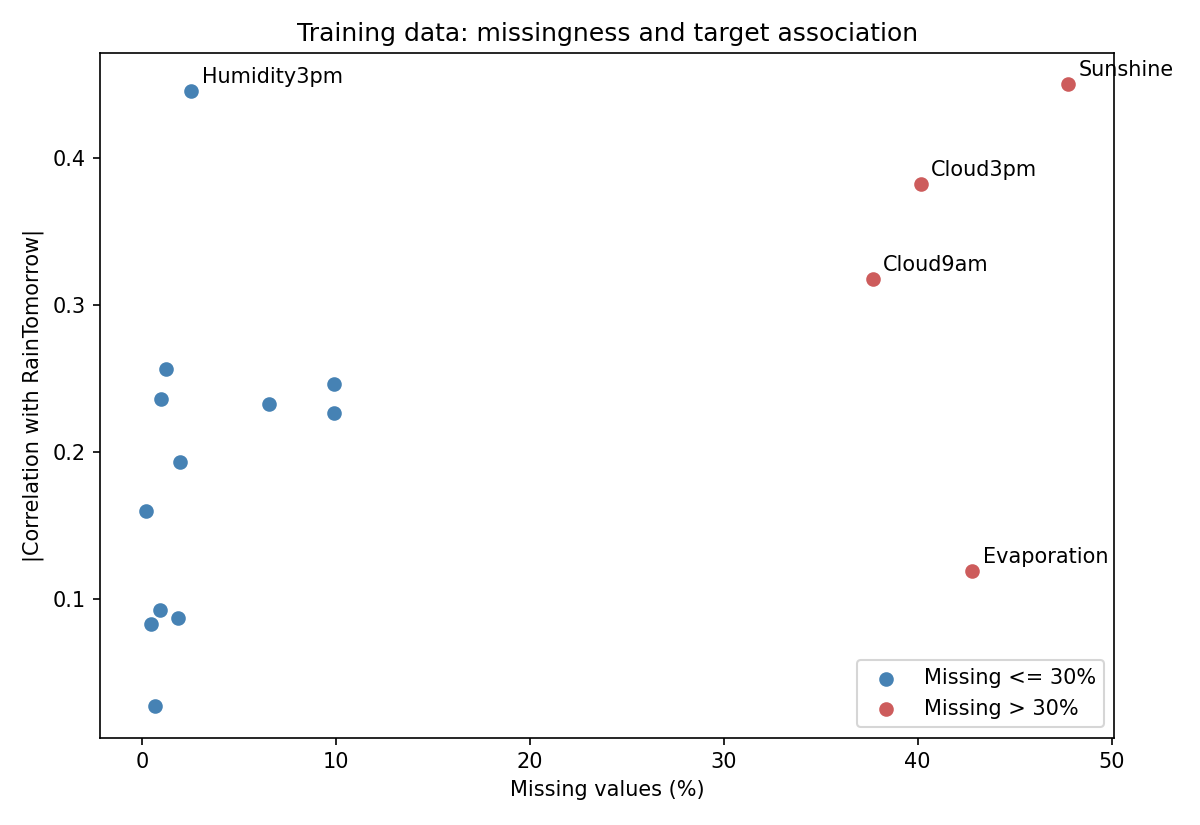

In [2]:
y_train = train_df['RainTomorrow'].eq('Yes').astype(int)
y_test = test_df['RainTomorrow'].eq('Yes').astype(int)
numeric = train_df.select_dtypes(include=np.number).columns
missing = train_df[numeric].isna().mean() * 100
correlation = train_df[numeric].corrwith(y_train)
missing_summary = pd.DataFrame({'missing_pct': missing, 'abs_correlation': correlation.abs()})
display(missing_summary.sort_values('missing_pct', ascending=False).round(3))
fig, ax = plt.subplots(figsize=(8, 5.5))
high_missing = missing_summary.missing_pct > 30
for flag, color, label in [(False, 'steelblue', 'Missing <= 30%'), (True, 'indianred', 'Missing > 30%')]:
    part = missing_summary[high_missing == flag]
    ax.scatter(part.missing_pct, part.abs_correlation, color=color, label=label)
for name, row in missing_summary.iterrows():
    if row.missing_pct > 30 or row.abs_correlation > 0.3:
        ax.annotate(name, (row.missing_pct, row.abs_correlation), xytext=(5, 4), textcoords='offset points')
ax.set(xlabel='Missing values (%)', ylabel='|Correlation with RainTomorrow|', title='Training data: missingness and target association')
ax.legend()
fig.tight_layout()
fig.savefig(image_dir / 'missing_rate_vs_predictive_power.png', dpi=150)
plt.show()


## 2. Cleaning and candidate features

Evaporation is dropped because its training-set association is relatively weak while its missing rate is high.
Sunshine and the cloud variables are kept and imputed. This is an exploratory choice, not proof that dropping
Evaporation is optimal. Feature choices made here are fixed before the later model search; its CV scores are
conditional on these choices, not a nested evaluation of the entire feature-selection process.

The raw Date string is not modelled. This does not establish that seasonality is absent.
TempRange and HumidityChange describe changes within a day. Their value must be checked in a model as well as by correlation.


Complete training rows after removing Evaporation: 46601 / 113754


,training_correlation
TempRange,-0.337
HumidityChange,0.268
PressureChange,0.080
CloudChange,0.047
WindChange,-0.005


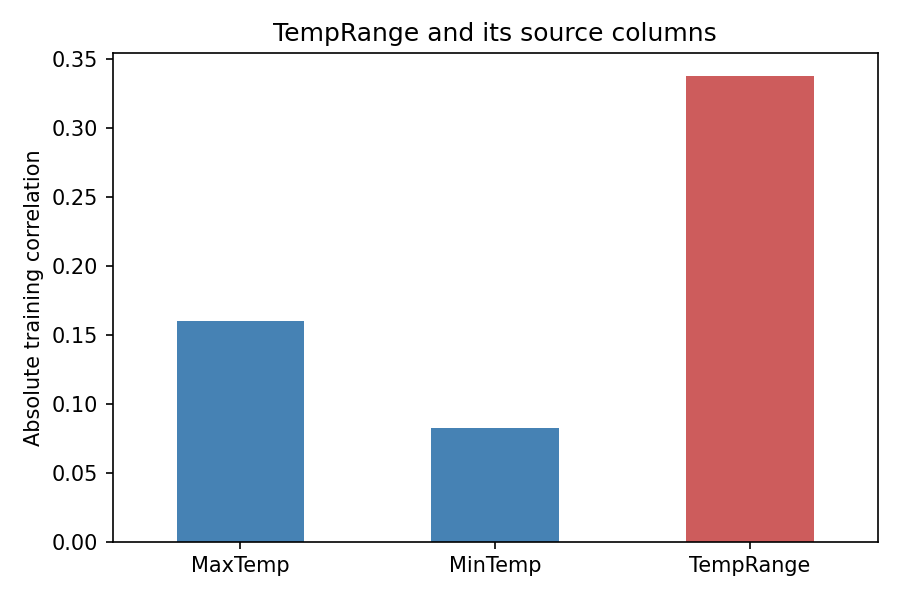

In [3]:
X_train = train_df.drop(columns=['RainTomorrow', 'Evaporation'])
X_test = test_df.drop(columns=['RainTomorrow', 'Evaporation'])
complete = X_train.dropna().shape[0]
print('Complete training rows after removing Evaporation:', complete, '/', len(X_train))
candidates = pd.DataFrame({
    'TempRange': X_train.MaxTemp - X_train.MinTemp,
    'HumidityChange': X_train.Humidity3pm - X_train.Humidity9am,
    'PressureChange': X_train.Pressure3pm - X_train.Pressure9am,
    'CloudChange': X_train.Cloud3pm - X_train.Cloud9am,
    'WindChange': X_train.WindSpeed3pm - X_train.WindSpeed9am,
})
display(candidates.corrwith(y_train).rename('training_correlation').to_frame().round(3))
source_comparison = pd.Series({
    'MaxTemp': X_train.MaxTemp.corr(y_train),
    'MinTemp': X_train.MinTemp.corr(y_train),
    'TempRange': candidates.TempRange.corr(y_train),
})
fig, ax = plt.subplots(figsize=(6, 4))
source_comparison.abs().plot.bar(ax=ax, rot=0, color=['steelblue', 'steelblue', 'indianred'])
ax.set(ylabel='Absolute training correlation', title='TempRange and its source columns')
fig.tight_layout()
fig.savefig(image_dir / 'temprange_vs_sources.png', dpi=150)
plt.show()


## 3. A switchable preprocessing pipeline

The transformer adds two row-wise differences. It learns no statistics.
Imputation, scaling and category encoding are fitted inside each model's pipeline.
Dtype-based selection handles both positions of the feature switch.


In [4]:
from sklearn.base import BaseEstimator, TransformerMixin


class WeatherFeatureAdder(BaseEstimator, TransformerMixin):
    """
    User-Defined Transformer: drops the raw `Date` column and, when
    `add_features=True`, adds TempRange (MaxTemp - MinTemp) and
    HumidityChange (Humidity3pm - Humidity9am).

    `add_features` is the switch required by Requirement (3) and is tuned
    as a hyperparameter in step (d).
    """

    def __init__(self, add_features=True):
        # scikit-learn requires constructor params to be stored unchanged,
        # under the same name, so that get_params/set_params/clone work.
        self.add_features = add_features

    def fit(self, X, y=None):
        # Nothing is learned from the data: the new features are computed row-wise.
        return self

    def transform(self, X):
        X = X.copy()

        # The raw date string cannot be used by a model, so it is always removed.
        if 'Date' in X.columns:
            X = X.drop(columns=['Date'])

        if self.add_features:
            X['TempRange'] = X['MaxTemp'] - X['MinTemp']
            X['HumidityChange'] = X['Humidity3pm'] - X['Humidity9am']

        return X


In [5]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric branch: fill missing with the median, then standardise
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Categorical branch: fill missing with the most frequent category, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Columns are selected by dtype so the transformer works whether or not
# the engineered features are present.
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    ('cat', categorical_pipeline, make_column_selector(dtype_include=object)),
])

# The complete preprocessing pipeline used by the models in steps (c) to (e)
preprocessing_pipeline = Pipeline([
    ('features', WeatherFeatureAdder(add_features=True)),   # the User-Defined Transformer from b-3
    ('preprocessor', preprocessor),
])

preprocessing_pipeline


Pipeline(steps=[('features', WeatherFeatureAdder()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1257c32d0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x1257c1010>)]))])

In [6]:
from sklearn.base import clone
for enabled in [False, True]:
    check = clone(preprocessing_pipeline).set_params(features__add_features=enabled)
    matrix = check.fit_transform(X_train)
    assert not np.isnan(matrix).any()
    print('add_features =', enabled, '| training shape =', matrix.shape)


add_features = False | training shape = (113754, 114)


add_features = True | training shape = (113754, 116)


## 4. Small model search

The original group used logistic regression, random forest and gradient boosting.
For a practical rerun, this version searches four configurations per model using three folds on a fixed
20,000-row sample drawn only from training data. This limits runtime; it is not an exhaustive search.
Each selected pipeline is then fitted on the full training partition.
F1 is for the rain class. The test partition is not used to select settings.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

X_search, _, y_search, _ = train_test_split(
    X_train, y_train, train_size=20000, stratify=y_train, random_state=42)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
model_specs = {
    'Logistic regression': (LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
        {'classifier__C': [0.1, 1, 10]}),
    'Random forest': (RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=42),
        {'classifier__max_depth': [10, 20]}),
    'Gradient boosting': (GradientBoostingClassifier(n_estimators=100, random_state=42),
        {'classifier__max_depth': [3, 5], 'classifier__learning_rate': [0.05, 0.1]}),
}
searches = {}
for name, (model, params) in model_specs.items():
    pipeline = Pipeline([('preprocessing', clone(preprocessing_pipeline)), ('classifier', model)])
    params = {**params, 'preprocessing__features__add_features': [False, True]}
    search = RandomizedSearchCV(pipeline, params, n_iter=4, cv=cv, scoring='f1',
                                random_state=42, n_jobs=1, refit=False, error_score='raise')
    search.fit(X_search, y_search)
    searches[name] = search
    print(name, '| search CV F1:', round(search.best_score_, 4), '|', search.best_params_, flush=True)


Logistic regression | search CV F1: 0.5965 | {'preprocessing__features__add_features': True, 'classifier__C': 10}


Random forest | search CV F1: 0.5734 | {'preprocessing__features__add_features': False, 'classifier__max_depth': 20}


Gradient boosting | search CV F1: 0.6041 | {'preprocessing__features__add_features': True, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1}


## 5. Feature toggle check

For each selected model configuration, compare ON and OFF with the other settings and folds held fixed.
This is a diagnostic on the same search data, not an independent validation. It avoids treating the
feature flag of a random-search winner as a measurement of the feature's effect.


In [8]:
from sklearn.model_selection import cross_val_score
toggle_rows = []
for name, search in searches.items():
    for enabled in [False, True]:
        candidate = clone(search.estimator).set_params(**search.best_params_)
        candidate.set_params(preprocessing__features__add_features=enabled)
        scores = cross_val_score(candidate, X_search, y_search, cv=cv, scoring='f1', n_jobs=1)
        toggle_rows.append({'model': name, 'add_features': enabled, 'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()})
toggle_results = pd.DataFrame(toggle_rows)
display(toggle_results.round(4))


,model,add_features,cv_f1_mean,cv_f1_std
0,Logistic regression,False,0.5931,0.0058
1,Logistic regression,True,0.5965,0.0041
2,Random forest,False,0.5734,0.0029
3,Random forest,True,0.5728,0.0052
4,Gradient boosting,False,0.6008,0.0027
5,Gradient boosting,True,0.6041,0.0080


## 6. Evaluation after selection

All selected settings come from the training-data search. A constant no-rain predictor provides context.
The feature-toggle diagnostic above does not change the selected settings.


In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
rows = []
fitted_models = {}
for name, search in searches.items():
    final = clone(search.estimator).set_params(**search.best_params_)
    final.fit(X_train, y_train)
    fitted_models[name] = final
    pred = final.predict(X_test)
    prob = final.predict_proba(X_test)[:, 1]
    rows.append({'model': name, 'accuracy': accuracy_score(y_test, pred),
                 'precision_rain': precision_score(y_test, pred, zero_division=0),
                 'recall_rain': recall_score(y_test, pred), 'f1_rain': f1_score(y_test, pred),
                 'roc_auc': roc_auc_score(y_test, prob)})
    print('Evaluated:', name, flush=True)
baseline = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(y_train), 1)), y_train)
base_pred = baseline.predict(np.zeros((len(y_test), 1)))
print('No-rain baseline accuracy:', accuracy_score(y_test, base_pred))
test_results = pd.DataFrame(rows)
display(test_results.round(4))
test_results.to_csv('../results.csv', index=False)
toggle_results.to_csv('../feature_toggle_results.csv', index=False)


Evaluated: Logistic regression


Evaluated: Random forest


Evaluated: Gradient boosting


No-rain baseline accuracy: 0.775835999859348


,model,accuracy,precision_rain,recall_rain,f1_rain,roc_auc
0,Logistic regression,0.8498,0.7355,0.5151,0.6059,0.8727
1,Random forest,0.8556,0.7883,0.4864,0.6016,0.8842
2,Gradient boosting,0.8548,0.7591,0.5159,0.6143,0.8837


## Limits

- Random row splitting can mix nearby dates and the same stations across partitions. These scores do not establish future-date or new-station performance.
- Initial feature choices are exploratory and use the training partition outside the search folds.
- The search covers few settings and only a training subset. Small CV differences are not decisive.
- Correlation ignores non-linear associations; median imputation can flatten highly incomplete columns.
- This revision corrects the workflow on previously explored data. A later time period would be a stronger external evaluation.
